# MATH 440: Mathematical Modeling
## Parameter Fitting Workshop

**Learning Goals:**
- Understand the least-squares criterion for model fitting
- Apply linear regression to fit simple models
- Use linearization to fit exponential and power-law models
- Use `scipy.optimize.curve_fit` for nonlinear models
- Assess model quality using residual plots and $R^2$

**Instructions:** Fill in code where you see `# YOUR CODE HERE`

---

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Part 1: Linear Regression (Review)

**The simplest case:** Fitting a straight line $y = a + bx$ to data.

**Least-squares criterion:** Minimize the sum of squared residuals:
$$\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Formulas:**
$$b = \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n\sum x_i^2 - (\sum x_i)^2}$$
$$a = \frac{\sum y_i - b \sum x_i}{n}$$

In [2]:
# Example: Linear data with noise
np.random.seed(42)

# Generate synthetic data: true relationship is y = 2 + 3x + noise
x_data = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_true = 2 + 3 * x_data
y_data = y_true + np.random.normal(0, 2, len(x_data))  # Add noise

# Compute least-squares coefficients by hand
n = len(x_data)
sum_x = np.sum(x_data)# YOUR CODE HERE
sum_y = np.sum(y_data)# YOUR CODE HERE
sum_xy = np.sum(x_data*y_data)# YOUR CODE HERE
sum_x2 = np.sum(x_data**2)# YOUR CODE HERE

b = (n*sum_xy-sum_x*sum_y)/(n*sum_x2-sum_x**2)
a = (sum_y-b*sum_x)/n

print(f"Fitted line: y = {a:.3f} + {b:.3f}x")
print(f"True line:   y = 2.000 + 3.000x")
print(f"\nIntercept error: {abs(a - 2):.3f}")
print(f"Slope error:     {abs(b - 3):.3f}")

Fitted line: y = 3.196 + 2.907x
True line:   y = 2.000 + 3.000x

Intercept error: 1.196
Slope error:     0.093


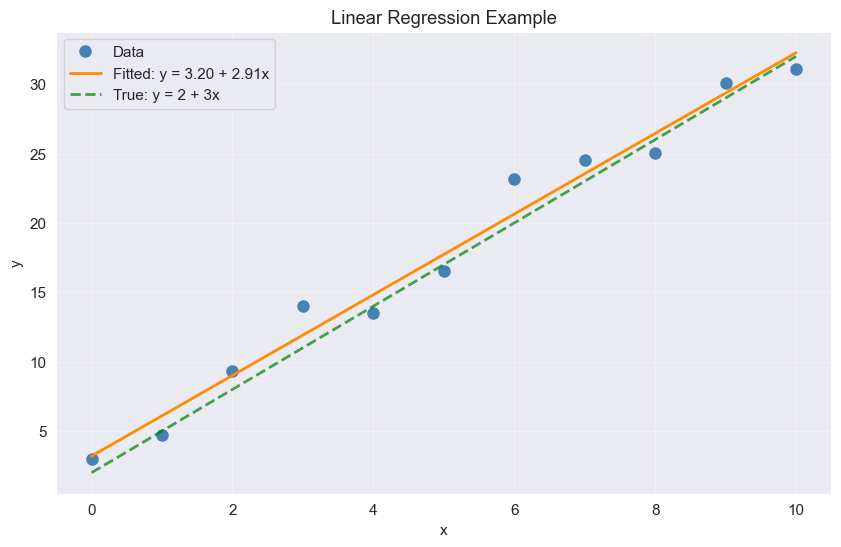

In [3]:
# Plot the data and fitted line
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, 'o', markersize=8, label='Data', color='steelblue')
plt.plot(x_data, a + b * x_data, '-', linewidth=2, label=f'Fitted: y = {a:.2f} + {b:.2f}x', color='darkorange')
plt.plot(x_data, y_true, '--', linewidth=2, label='True: y = 2 + 3x', color='green', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Example')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Part 2: Exponential Decay Fitting (with Linearization)

**Model:** $y(t) = y_0 e^{-kt}$

**Linearization:**
$$\ln(y) = \ln(y_0) - kt$$

Set $Y = \ln(y)$, then fit $Y = a + bt$ where $a = \ln(y_0)$ and $b = -k$.

In [4]:
# Example: Radioactive decay data
np.random.seed(123)

t_data = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
N0_true = 100
k_true = 0.15

N_true = N0_true * np.exp(-k_true * t_data)
N_data = N_true * np.random.uniform(0.9, 1.1, len(t_data))  # multiplicative noise

print("Time (hours) | Count")
print("-" * 25)
for t, N in zip(t_data, N_data):
    print(f"{t:12.0f} | {N:6.2f}")

Time (hours) | Count
-------------------------
           0 | 103.93
           2 |  70.91
           4 |  51.88
           6 |  41.07
           8 |  31.44
          10 |  21.97
          12 |  18.12
          14 |  12.70
          16 |   9.04
          18 |   6.58
          20 |   4.82


### Method 1: Linearization

In [5]:
# Step 1: Transform data
Y_data = np.log(N_data)

# Step 2: Fit linear model Y = a + b*t
n = len(t_data)
sum_t =  np.sum(t_data)
sum_Y =  np.sum(Y_data)
sum_tY = np.sum(t_data*Y_data)
sum_t2 = np.sum(t_data**2)


b = (n*sum_tY-sum_t*sum_Y)/(n*sum_t2-sum_t**2)
a = (sum_Y-b*sum_t)/n

# Step 3: Convert back to original parameters
N0_fit = np.exp(a) # YOUR CODE HERE
k_fit = -b# YOUR CODE HERE  # Hint: watch the sign!

print("\n=== Linearization Method ===")
print(f"Fitted model: N(t) = {N0_fit:.2f} * exp(-{k_fit:.4f} * t)")
print(f"True model:   N(t) = {N0_true:.2f} * exp(-{k_true:.4f} * t)")
print(f"\nN0 error: {abs(N0_fit - N0_true):.2f}")
print(f"k error:  {abs(k_fit - k_true):.4f}")


=== Linearization Method ===
Fitted model: N(t) = 100.46 * exp(-0.1500 * t)
True model:   N(t) = 100.00 * exp(-0.1500 * t)

N0 error: 0.46
k error:  0.0000


# User
yes

In [6]:
# Assistant
# Step 1: Transform data
Y_data = np.log(N_data)

# Step 2: Fit linear model Y = a + b*t
n = len(t_data)
sum_t =  np.sum(t_data)
sum_Y =  np.sum(Y_data)
sum_tY = np.sum(t_data*Y_data)
sum_t2 = np.sum(t_data**2)

b = (n*sum_tY-sum_t*sum_Y)/(n*sum_t2-sum_t**2)
a = (sum_Y-b*sum_t)/n

# Step 3: Convert back to original parameters
N0_fit = np.exp(a)  # N0 is e^a since Y = ln(N) = a + b*t
k_fit = -b  # k is -b because in decay model N(t) = N0*exp(-k*t)

print("\n=== Linearization Method ===")
print(f"Fitted model: N(t) = {N0_fit:.2f} * exp(-{k_fit:.4f} * t)")
print(f"True model:   N(t) = {N0_true:.2f} * exp(-{k_true:.4f} * t)")
print(f"\nN0 error: {abs(N0_fit - N0_true):.2f}")
print(f"k error:  {abs(k_fit - k_true):.4f}")


=== Linearization Method ===
Fitted model: N(t) = 100.46 * exp(-0.1500 * t)
True model:   N(t) = 100.00 * exp(-0.1500 * t)

N0 error: 0.46
k error:  0.0000


In [7]:
# Assistant
# Step 1: Transform data
Y_data = np.log(N_data)

# Step 2: Fit linear model Y = a + b*t
n = len(t_data)
sum_t =  np.sum(t_data)
sum_Y =  np.sum(Y_data)
sum_tY = np.sum(t_data*Y_data)
sum_t2 = np.sum(t_data**2)

b = (n*sum_tY-sum_t*sum_Y)/(n*sum_t2-sum_t**2)
a = (sum_Y-b*sum_t)/n

# Step 3: Convert back to original parameters
N0_fit = np.exp(a)  # N0 is e^a since Y = ln(N) = a + b*t
k_fit = -b  # k is -b because in decay model N(t) = N0*exp(-k*t)

print("\n=== Linearization Method ===")
print(f"Fitted model: N(t) = {N0_fit:.2f} * exp(-{k_fit:.4f} * t)")
print(f"True model:   N(t) = {N0_true:.2f} * exp(-{k_true:.4f} * t)")
print(f"\nN0 error: {abs(N0_fit - N0_true):.2f}")
print(f"k error:  {abs(k_fit - k_true):.4f}")


=== Linearization Method ===
Fitted model: N(t) = 100.46 * exp(-0.1500 * t)
True model:   N(t) = 100.00 * exp(-0.1500 * t)

N0 error: 0.46
k error:  0.0000


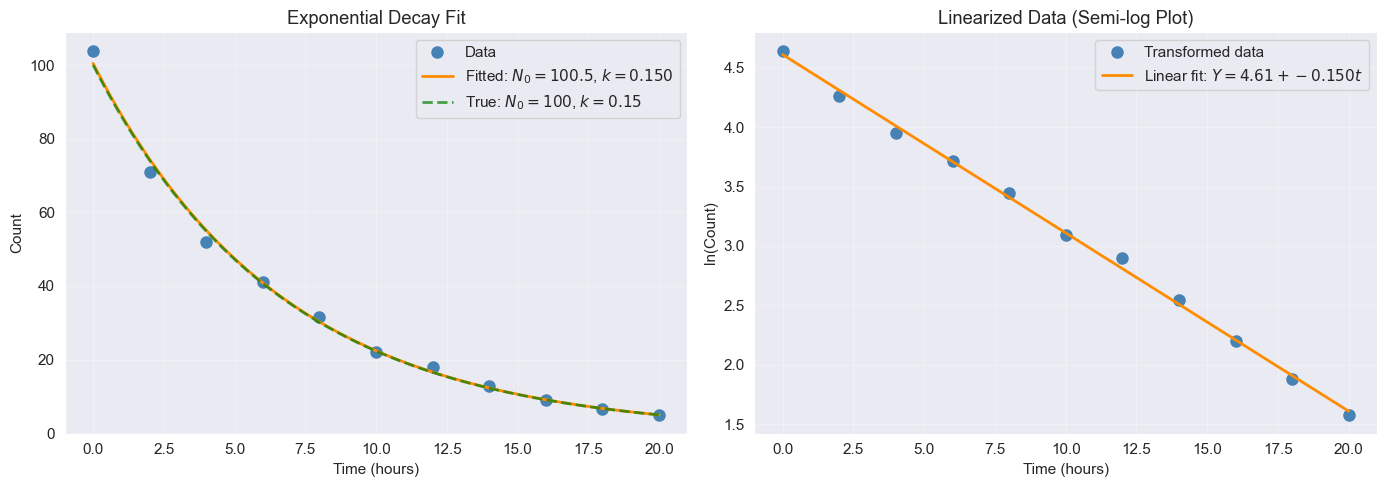

In [8]:
# Plot original data and fitted exponential
t_smooth = np.linspace(0,20,100) # YOUR CODE HERE
N_fit = N0_fit * np.exp(-k_fit*t_smooth)# YOUR CODE HERE  # Hint: N0_fit * np.exp(-k_fit * t_smooth)
N_true_smooth = N0_true * np.exp(-k_true * t_smooth)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Original scale
ax1.plot(t_data, N_data, 'o', markersize=8, label='Data', color='steelblue')
ax1.plot(t_smooth, N_fit, '-', linewidth=2, 
         label=rf'Fitted: $N_0={N0_fit:.1f}$, $k={k_fit:.3f}$', color='darkorange')
ax1.plot(t_smooth, N_true_smooth, '--', linewidth=2, 
         label=rf'True: $N_0={N0_true}$, $k={k_true}$', color='green', alpha=0.7)
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Count')
ax1.set_title('Exponential Decay Fit')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Log scale (shows linearity)
ax2.plot(t_data, Y_data, 'o', markersize=8, label='Transformed data', color='steelblue')
ax2.plot(t_smooth, a + b * t_smooth, '-', linewidth=2, 
         label=rf'Linear fit: $Y = {a:.2f} + {b:.3f}t$', color='darkorange')
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('ln(Count)')
ax2.set_title('Linearized Data (Semi-log Plot)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Method 2: Direct Nonlinear Fitting with `curve_fit`

In [9]:
# Define the model function
def exponential_model(t, N0, k):
    return N0 * np.exp(-k * t)

# Fit using curve_fit
params_nonlin, covariance = curve_fit(exponential_model, t_data, N_data, p0=[100, 0.1])
N0_nonlin, k_nonlin = params_nonlin
std_errors = np.sqrt(np.diag(covariance))

print("\n=== Nonlinear Fitting (curve_fit) ===")
print(f"Fitted model: N(t) = {N0_nonlin:.2f} ± {std_errors[0]:.2f} * exp(-{k_nonlin:.4f} ± {std_errors[1]:.4f} * t)")
print(f"True model:   N(t) = {N0_true:.2f} * exp(-{k_true:.4f} * t)")
print(f"\nN0 error: {abs(N0_nonlin - N0_true):.2f}")
print(f"k error:  {abs(k_nonlin - k_true):.4f}")


=== Nonlinear Fitting (curve_fit) ===
Fitted model: N(t) = 101.00 ± 1.72 * exp(-0.1528 ± 0.0044 * t)
True model:   N(t) = 100.00 * exp(-0.1500 * t)

N0 error: 1.00
k error:  0.0028


---
## Part 3: Logistic Growth Fitting

**Model:** $$x(t) = \frac{K}{1 + Ae^{-rt}}$$ where $A = \frac{K - x_0}{x_0}$

Equivalently:
$$x(t) = \frac{K}{1 + \left(\frac{K - x_0}{x_0}\right)e^{-rt}}$$

**Parameters:**
- $K$ is the carrying capacity (asymptotic maximum)
- $r$ is the growth rate (per unit time)
- $x_0$ is the initial population at $t = 0$

**Challenge:** This model **cannot be easily linearized**, so we use `curve_fit` directly.

**Key to success:** Good initial guesses and parameter bounds!

### Example: Bacterial Growth

In [10]:
# Generate synthetic logistic growth data
# IMPORTANT: Make sure x0 corresponds to actual first data point
np.random.seed(456)

t_bac = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
K_true = 500  # Carrying capacity
r_true = 0.6  # Growth rate
x0_true = 10  # Initial population

A_true = (K_true - x0_true) / x0_true
x_true = K_true / (1 + A_true * np.exp(-r_true * t_bac))
x_bac = x_true + np.random.normal(0, 15, len(t_bac))  # Add noise
x_bac = np.clip(x_bac, 1, None)  # Ensure all values are positive

print("Time (hours) | Population")
print("-" * 30)
for t, x in zip(t_bac, x_bac):
    print(f"{t:12.0f} | {x:10.1f}")

Time (hours) | Population
------------------------------
           0 |        1.0
           1 |       10.5
           2 |       41.0
           3 |       63.5
           4 |      112.1
           5 |      169.8
           6 |      218.3
           7 |      295.0
           8 |      351.1
           9 |      404.7
          10 |      415.6
          11 |      451.8
          12 |      465.7


In [11]:
# Define logistic model (standard parameterization)
def logistic_model(t, K, r, x0):
    """
    Standard logistic growth model: x(t) = K / (1 + A*exp(-r*t))
    where A = (K - x0) / x0
    
    Parameters:
    - K: carrying capacity (maximum sustainable population)
    - r: intrinsic growth rate (per unit time)
    - x0: initial population at t=0
    """
    A = (K - x0) / x0
    return K / (1 + A * np.exp(-r * t))

# CRITICAL: Smart initial guesses
# Strategy:
#   - K should be above maximum observed value (data may not have reached K yet)
#   - r around 0.5 is reasonable for many biological systems
#   - x0 should be close to first data point

K_guess =max(x_bac) * 1.5 # Hint: max(x_bac) * 1.5  # Assume K is 50% above max observed
r_guess = 0.5 # YOUR CODE HERE  # Hint: 0.5               # Moderate growth rate
x0_guess = x_bac[0] # YOUR CODE HERE  # Hint: x_bac[0]         # Use first data point

p0 = [K_guess, r_guess, x0_guess]

# CRITICAL: Set bounds to prevent nonsensical values
# Lower bounds: K > max(data), r > 0, x0 > 0
# Upper bounds: K can be large, r < 10 (very fast growth), x0 < max(data)


bounds = (
    [max(x_bac) * 1.01, 0.01, 0.1],      # Lower bounds
    [np.inf, 10, max(x_bac) * 0.99]      # Upper bounds
)

# Fit the model
params_logistic, cov_logistic = curve_fit(
    logistic_model, t_bac, x_bac, 
    p0=p0, 
    bounds=bounds,
    maxfev=10000  # Allow more iterations if needed
)

K_fit, r_fit, x0_fit = params_logistic
std_errors_log = np.sqrt(np.diag(cov_logistic))

print("\n=== Logistic Growth Fit ===")
print(f"Fitted parameters:")
print(f"  K (carrying capacity) = {K_fit:.1f} ± {std_errors_log[0]:.1f}")
print(f"  r (growth rate)       = {r_fit:.3f} ± {std_errors_log[1]:.3f} per hour")
print(f"  x0 (initial pop)      = {x0_fit:.1f} ± {std_errors_log[2]:.1f}")

print(f"\nTrue parameters:")
print(f"  K  = {K_true:.1f}")
print(f"  r  = {r_true:.3f} per hour")
print(f"  x0 = {x0_true:.1f}")

print(f"\nParameter errors:")
print(f"  K error:  {abs(K_fit - K_true):.1f}")
print(f"  r error:  {abs(r_fit - r_true):.3f}")
print(f"  x0 error: {abs(x0_fit - x0_true):.1f}")

# Compute and display inflection point
t_inflection = np.log((K_fit - x0_fit) / x0_fit) / r_fit
x_inflection = K_fit / 2
print(f"\nInflection point (maximum growth rate):")
print(f"  Time: t = {t_inflection:.1f} hours")
print(f"  Population: x = {x_inflection:.1f} (exactly K/2)")


=== Logistic Growth Fit ===
Fitted parameters:
  K (carrying capacity) = 476.3 ± 8.5
  r (growth rate)       = 0.577 ± 0.026 per hour
  x0 (initial pop)      = 13.2 ± 1.8

True parameters:
  K  = 500.0
  r  = 0.600 per hour
  x0 = 10.0

Parameter errors:
  K error:  23.7
  r error:  0.023
  x0 error: 3.2

Inflection point (maximum growth rate):
  Time: t = 6.2 hours
  Population: x = 238.2 (exactly K/2)


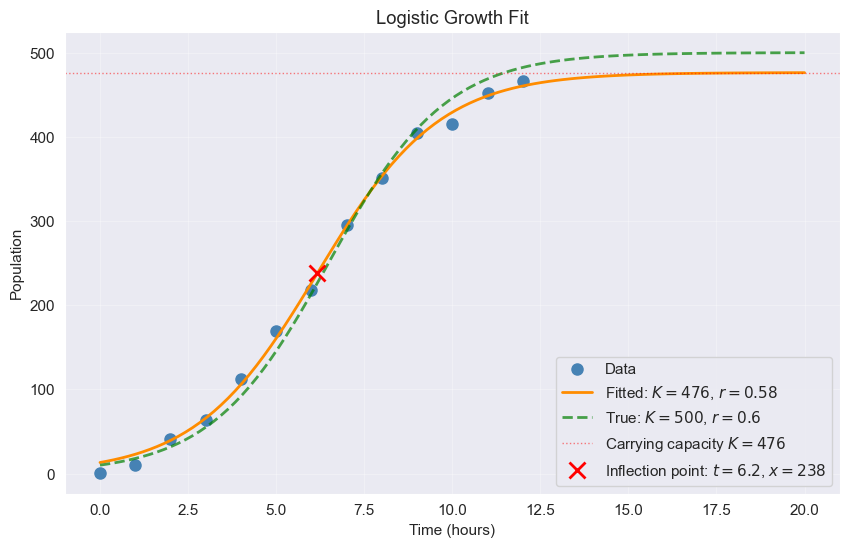

In [12]:
# Plot data and fitted curve
t_smooth =  np.linspace(0,20,100)
x_fit = logistic_model(t_smooth, K_fit, r_fit, x0_fit)
x_true_smooth = logistic_model(t_smooth, K_true, r_true, x0_true)

# Compute inflection point
t_inflection = np.log((K_fit - x0_fit) / x0_fit) / r_fit
x_inflection = K_fit / 2

plt.figure(figsize=(10, 6))
plt.plot(t_bac, x_bac, 'o', markersize=8, label='Data', color='steelblue')
plt.plot(t_smooth, x_fit, '-', linewidth=2, 
         label=rf'Fitted: $K={K_fit:.0f}$, $r={r_fit:.2f}$', color='darkorange')
plt.plot(t_smooth, x_true_smooth, '--', linewidth=2, 
         label=rf'True: $K={K_true}$, $r={r_true}$', color='green', alpha=0.7)

# Mark carrying capacity and inflection point
plt.axhline(K_fit, color='red', linestyle=':', linewidth=1, alpha=0.5, 
            label=rf'Carrying capacity $K={K_fit:.0f}$')
plt.plot(t_inflection, x_inflection, 'rx', markersize=12, markeredgewidth=2,
         label=rf'Inflection point: $t={t_inflection:.1f}$, $x={x_inflection:.0f}$')

plt.xlabel('Time (hours)')
plt.ylabel('Population')
plt.title('Logistic Growth Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Key Lessons from Logistic Fitting

**Why did this work (when it failed before)?**

1. **Better initial guess for $K$:** We used `max(data) * 1.5` instead of just `max(data)`
   - If data hasn't reached carrying capacity yet, `max(data)` underestimates $K$
   - Giving optimizer room to find larger $K$ helps convergence

2. **Smart $x_0$ guess:** We used the first data point `x_bac[0]`
   - This is the actual initial value in the data
   - Much better than guessing `min(data)` which could be anywhere

3. **Bounds enforce physical constraints:**
   - $K > \max(\text{data})$: Carrying capacity must be at least as large as observed maximum
   - $0 < x_0 < \max(\text{data})$: Initial population must be positive but less than any observed value
   - $r > 0$: Growth rate must be positive

4. **Allowed more iterations:** `maxfev=10000` gives optimizer time to converge

**General advice for nonlinear fitting:**
- Inspect your data first (plot it!)
- Use domain knowledge to set reasonable initial guesses
- Always use bounds to prevent nonsensical parameter values
- If fitting fails, try different initial guesses or tighter bounds

---
## Part 4: Model Quality Assessment

### Residual Analysis

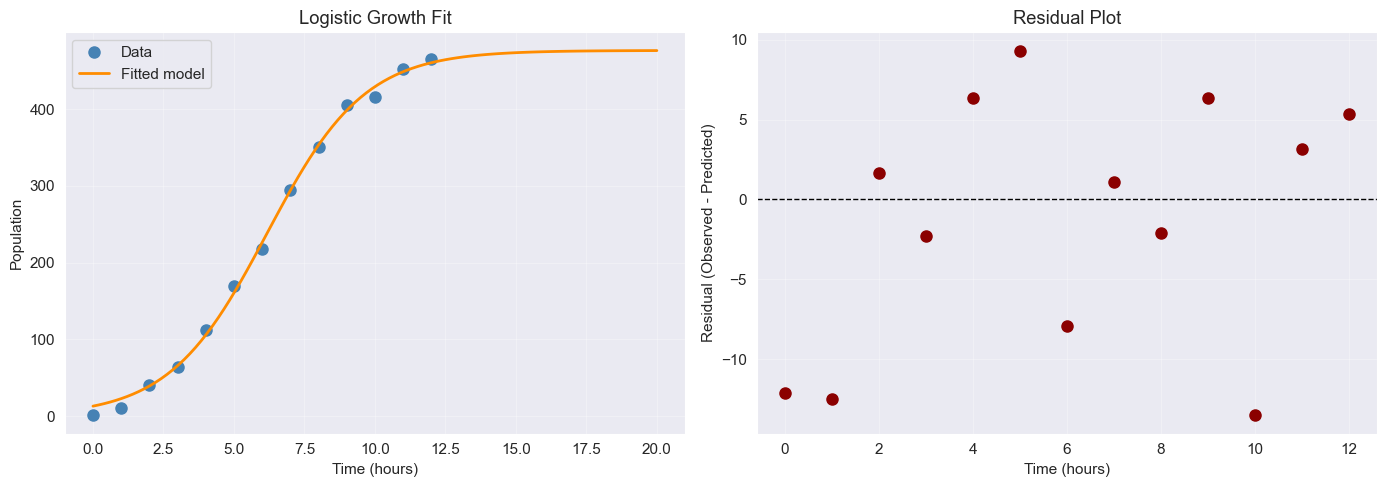


Residual Analysis:
Mean residual:     -1.33 (should be ≈ 0)
Std dev residual:  7.57
Max |residual|:    13.53


In [13]:
# Compute residuals
x_pred = logistic_model(t_bac, K_fit, r_fit, x0_fit)
residuals = x_bac - x_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Data and fit
ax1.plot(t_bac, x_bac, 'o', markersize=8, label='Data', color='steelblue')
ax1.plot(t_smooth, x_fit, '-', linewidth=2, label='Fitted model', color='darkorange')
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Population')
ax1.set_title('Logistic Growth Fit')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Residuals
ax2.plot(t_bac, residuals, 'o', markersize=8, color='darkred')
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Residual (Observed - Predicted)')
ax2.set_title('Residual Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResidual Analysis:")
print(f"Mean residual:     {np.mean(residuals):.2f} (should be ≈ 0)")
print(f"Std dev residual:  {np.std(residuals):.2f}")
print(f"Max |residual|:    {np.max(np.abs(residuals)):.2f}")

### R² Calculation

In [14]:
# Compute R²
SSE = np.sum(residuals**2)
SST = np.sum((x_bac - np.mean(x_bac))**2)
R2 = 1 - SSE/SST

print(f"\nGoodness of Fit:")
print(f"  SSE (sum of squared errors):  {SSE:.2f}")
print(f"  SST (total sum of squares):   {SST:.2f}")
print(f"  R² (coefficient of determination): {R2:.4f}")

if R2 > 0.95:
    print(f"\n  ✓ Excellent fit! Model explains {100*R2:.1f}% of variance.")
elif R2 > 0.8:
    print(f"\n  ✓ Good fit. Model explains {100*R2:.1f}% of variance.")
else:
    print(f"\n  ⚠ Moderate fit. Model explains {100*R2:.1f}% of variance.")


Goodness of Fit:
  SSE (sum of squared errors):  768.32
  SST (total sum of squares):   370335.68
  R² (coefficient of determination): 0.9979

  ✓ Excellent fit! Model explains 99.8% of variance.


---
## Part 5: Practice Problem

**Drug elimination:** Blood concentration measured over 24 hours.

**Model:** $C(t) = C_0 e^{-kt}$

**Your tasks:**
1. Fit using linearization
2. Fit using `curve_fit`
3. Compare methods
4. Create residual plot
5. Compute $R^2$
6. Calculate half-life: $t_{1/2} = \ln(2)/k$

In [15]:
# Drug concentration data
t_drug = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
C_drug = np.array([95.2, 83.1, 72.5, 63.8, 55.2, 48.9, 42.1, 37.2, 32.8, 28.5, 24.9, 21.8, 19.1])

print("Drug Concentration Data:")
print("Time (hours) | Concentration (mg/L)")
print("-" * 40)
for t, C in zip(t_drug, C_drug):
    print(f"{t:12.0f} | {C:20.1f}")

n = len(t_drug)
sum_t = np.sum(t_drug)
sum_C = np.sum(C_drug)
sum_tC = np.sum(t_drug*C_drug)
sum_t2 = np.sum(t_drug**2)

b = (n*sum_tC-sum_t*sum_C)/(n*sum_t2-sum_t**2)
a = (sum_C-b*sum_t)/n

# Step 3: Convert back to original parameters
C0_fit = np.exp(a)  # C0 is e^a since Y = ln(C) = a + b*t
k_fit = -b  # k is -b because in decay model C(t) = C0*exp(-k*t)

def exponential_model(t, C0, k):
    return C0 * np.exp(-k * t)  # Changed N0 to C0 to match parameter name

# Fit using curve_fit
params_nonlin, covariance = curve_fit(exponential_model, t_drug, C_drug, p0=[100, 0.1])
C0_nonlin, k_nonlin = params_nonlin
std_errors = np.sqrt(np.diag(covariance))

# Define true model parameters or remove these lines if they're not needed
C0_true = 100  # Replace with actual value if known
k_true = 0.1   # Replace with actual value if known

print("\n=== Nonlinear Fitting (curve_fit) ===")
print(f"Fitted model: C(t) = {C0_nonlin:.2f} ± {std_errors[0]:.2f} * exp(-{k_nonlin:.4f} ± {std_errors[1]:.4f} * t)")
print(f"True model:   C(t) = {C0_true:.2f} * exp(-{k_true:.4f} * t)")
print(f"\nC0 error: {abs(C0_nonlin - C0_true):.2f}")
print(f"k error:  {abs(k_nonlin - k_true):.4f}")

# YOUR CODE HERE
# Hint: Follow the exponential fitting examples from Part 2

Drug Concentration Data:
Time (hours) | Concentration (mg/L)
----------------------------------------
           0 |                 95.2
           2 |                 83.1
           4 |                 72.5
           6 |                 63.8
           8 |                 55.2
          10 |                 48.9
          12 |                 42.1
          14 |                 37.2
          16 |                 32.8
          18 |                 28.5
          20 |                 24.9
          22 |                 21.8
          24 |                 19.1

=== Nonlinear Fitting (curve_fit) ===
Fitted model: C(t) = 95.04 ± 0.16 * exp(-0.0670 ± 0.0002 * t)
True model:   C(t) = 100.00 * exp(-0.1000 * t)

C0 error: 4.96
k error:  0.0330


---
## Summary: Key Takeaways

1. **Least-squares minimizes sum of squared residuals**
2. **Linearization transforms nonlinear models → linear**
3. **`curve_fit` handles any model but needs:**
   - Good initial guess (`p0`)
   - Stable parameterization
   - Reasonable bounds
4. **Residual plots reveal model quality**
5. **$R^2$ quantifies goodness of fit**

**For logistic models:**
- Use $x(t) = K/(1 + e^{-r(t-L)})$ parameterization (stable)
- NOT $x(t) = K/(1 + Ae^{-rt})$ with $A = (K-x_0)/x_0$ (unstable)

---